In [2]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
Allstates <- read.table('all.peaks.clean.center200.states.matrix',header=T,row.names = 1)

In [4]:
mGC2peaks <- read.table('GC2.spec.hub.isct.bed')
mGC3peaks <- read.table('GC3.spec.hub.isct.bed')

In [5]:
sharedpeaks <- read.table('Shared_hubs.isct.bed')

In [6]:
paste(mGC2peaks$V1,mGC2peaks$V2,mGC2peaks$V3,sep="_") -> mGC2peaks
paste(mGC3peaks$V1,mGC3peaks$V2,mGC3peaks$V3,sep="_") -> mGC3peaks

In [7]:
paste(sharedpeaks$V1,sharedpeaks$V2,sharedpeaks$V3,sep="_") -> sharedpeaks

In [8]:
phe <- readRDS('phe3.Rds')
phe  %>% filter(footprint=='C2')  %>% rownames()  -> C2names
phe  %>% filter(footprint=='C3')  %>% rownames()  -> C3names

In [9]:
Allstates[sharedpeaks,] -> Sharedstates

In [10]:
Allstates[mGC2peaks,C2names] -> C2states
Allstates[mGC3peaks,C3names] -> C3states

In [11]:
levels = c('ActiveTSS','TssFlank','TssFlankD','TxFlank','EnhA1','EnhA2',
                                            'EnhPoised1','EnhPoised2','EnhPrimed','EnhBivalent','ReprPC')

In [12]:
states <- levels

In [13]:
color <- c("#a50026","#d73027","#f46d43","#fdae61","#fee08b","#ffffbf","#d9ef8b",
                                "#a6d96a","#66bd63","#1a9850","#1886a0","#dbdddc","#bbbcbb","#bbbcbb","#8e8e8e",
                               "#727272")

In [14]:
names(color) <- states

In [15]:
get_freq <- function(states){
    count_matrix_C1 <- sapply(states, function(col) {
      tbl <- table(factor(col, levels = levels))
      as.numeric(tbl)
    })
    rownames(count_matrix_C1) <- levels
    C1_peak_freq <- sweep(count_matrix_C1, 2, colSums(count_matrix_C1), FUN = "/")
    return(C1_peak_freq)
}

In [16]:
All_peak_freq <- get_freq(Allstates)
Shared_peak_freq <- get_freq(Sharedstates)
C2_peak_freq <- get_freq(C2states)
C3_peak_freq <- get_freq(C3states)

In [17]:
All_peak_freq[!All_peak_freq  %>% rownames()  %>% str_detect('Low'),]      -> All_peak_freq2
Shared_peak_freq[!Shared_peak_freq  %>% rownames()  %>% str_detect('Low'),]-> Shared_peak_freq2

C2_peak_freq[!C2_peak_freq  %>% rownames()  %>% str_detect('Low'),C2names] -> C2_peak_freq2
C3_peak_freq[!C3_peak_freq  %>% rownames()  %>% str_detect('Low'),C3names] -> C3_peak_freq2

In [18]:
apply(All_peak_freq2, 2, function(x) x / sum(x)) -> All_peak_freq3
apply(Shared_peak_freq2, 2, function(x) x / sum(x)) -> Shared_peak_freq3

apply(C2_peak_freq2, 2, function(x) x / sum(x)) -> C2_peak_freq3
apply(C3_peak_freq2, 2, function(x) x / sum(x)) -> C3_peak_freq3

In [19]:
states[!states  %>% str_detect('Low')] -> states

In [20]:
data_for_bar <- data.frame(#All=rowMeans(All_peak_freq3)[states],
                           Shared=rowMeans(Shared_peak_freq3)[states] , 
                               C2=rowMeans(C2_peak_freq3)[states],                               
                               C3=rowMeans(C3_peak_freq3)[states])

In [21]:
data_for_bar$states <- states
data_for_bar2 <- pivot_longer(data =data_for_bar,!states, names_to = "Group", values_to = "Proportion")
data_for_bar2$states <- factor(data_for_bar2$states,levels=levels)
data_for_bar2$states  <- factor(data_for_bar2$states,
                                 levels = levels)

In [22]:
options(repr.plot.height=6,repr.plot.width=4)
p_bar <- ggplot(data = data_for_bar2,aes(x=Group,y=Proportion,fill=states))+
    geom_bar(stat="identity") + theme_bw() + xlab("") +theme(axis.text = element_text(color="black",size=10))+
    scale_fill_manual(values = color) + theme(axis.text.x = element_text(angle = 45,hjust = 1))

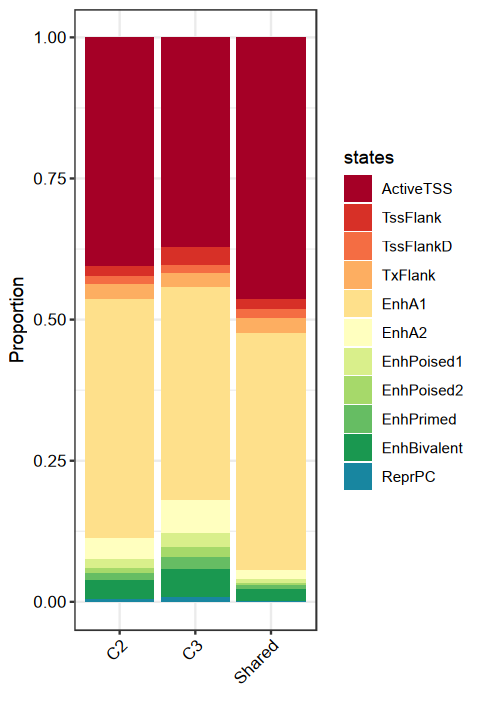

In [23]:
options(repr.plot.height=6,repr.plot.width=4)
p_bar

In [24]:
ggsave(plot = p_bar, filename = 'C2_C3_Shared_bar.pdf', width = 4, height = 6)

### for box

In [25]:
Shared_peak_freq2 <- as.data.frame(Shared_peak_freq2[states,])

In [26]:
C2_peak_freq2 <- as.data.frame(C2_peak_freq3[states,C2names])
C3_peak_freq2 <- as.data.frame(C3_peak_freq3[states,C3names])

In [27]:
C2_peak_freq2$states <- rownames(C2_peak_freq2)
C3_peak_freq2$states <- rownames(C3_peak_freq2)
Shared_peak_freq2$states <- rownames(Shared_peak_freq2)

In [28]:
C2_peak_freq2_forbox <- pivot_longer(data =C2_peak_freq2,!states, names_to = "sample", values_to = "Proportion" )
C3_peak_freq2_forbox <- pivot_longer(data =C3_peak_freq2,!states, names_to = "sample", values_to = "Proportion" )
Shared_peak_freq2_forbox <- pivot_longer(data =Shared_peak_freq2,!states, names_to = "sample", values_to = "Proportion" )

In [29]:
C2_peak_freq2_forbox$group <- "C2"
C3_peak_freq2_forbox$group <- "C3"
Shared_peak_freq2_forbox$group <- "Shared"

In [30]:
rbind(Shared_peak_freq2_forbox,C2_peak_freq2_forbox,C3_peak_freq2_forbox)  -> Shared_C2_C3_order_forbox_comb

In [31]:
Shared_C2_C3_order_forbox_comb$states <- factor(Shared_C2_C3_order_forbox_comb$states,levels=states)

In [32]:
compare_list2 <- list(c("Shared","C3"),c("C2","Shared"),c('C2','C3'))

In [33]:
#compare_list2 <- list(c("C2","C3"))

In [34]:
Shared_C2_C3_order_forbox_comb$group <- factor(Shared_C2_C3_order_forbox_comb$group,
                                               levels = c("Shared","C2","C3"))

In [35]:
library(ggpubr)

In [36]:
p1 <- ggboxplot(Shared_C2_C3_order_forbox_comb,x="group", y="Proportion", add="jitter",add.params=list(shape=21, fill="orange", size=1.5)
         )+geom_signif(comparisons = compare_list2,step_increase = 0.1,map_signif_level = F,test = t.test
                      ) + scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
        ylab("Proportion") + facet_wrap(~states, scale="free")

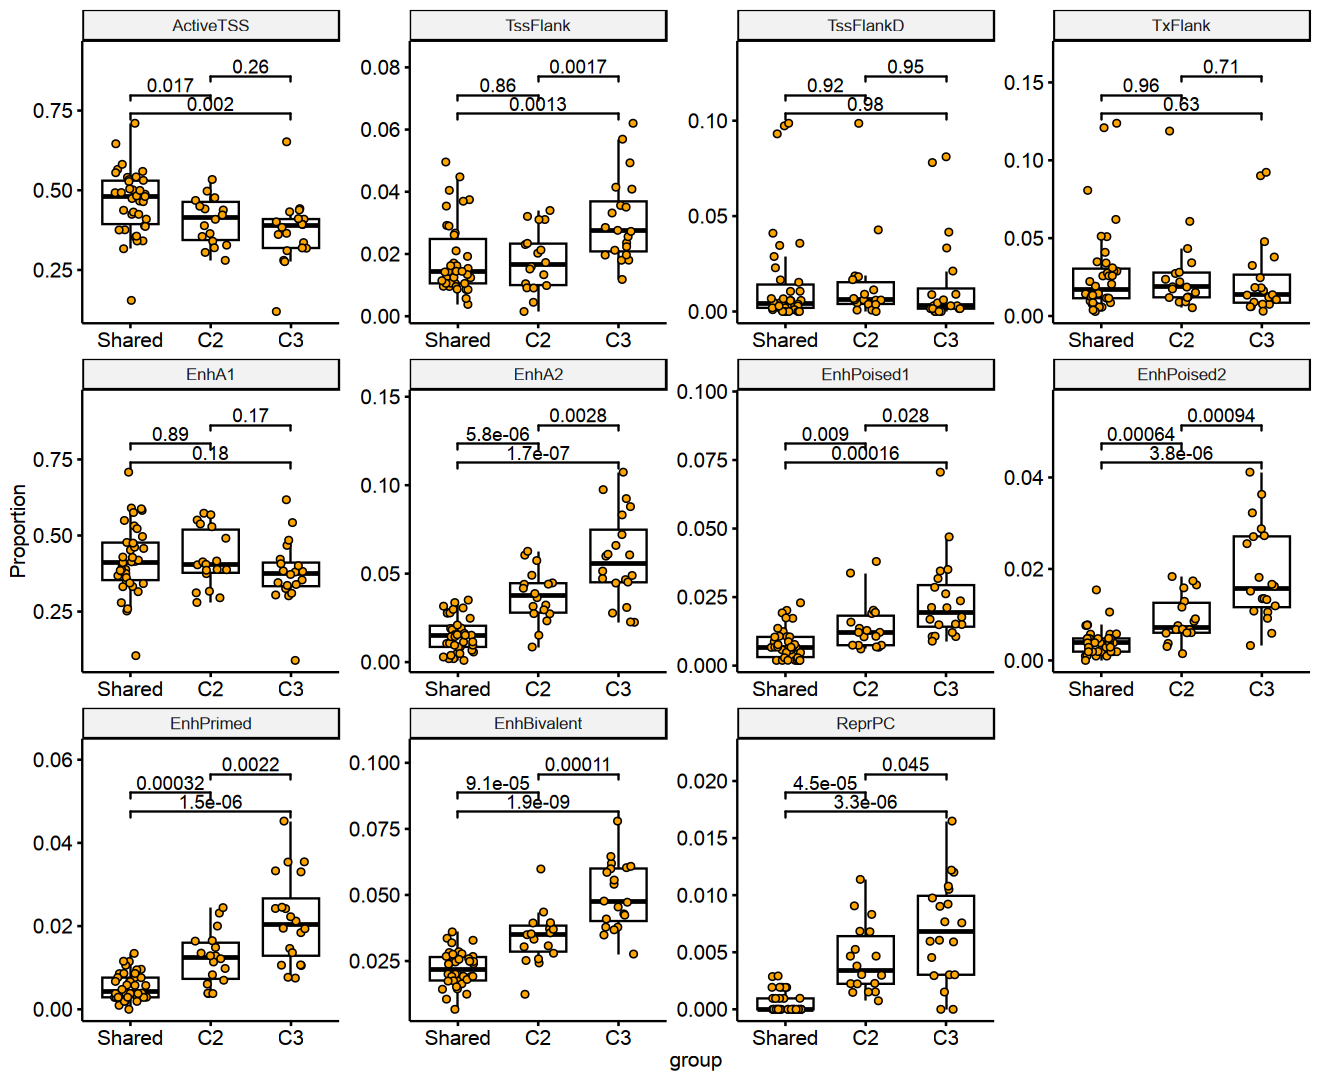

In [39]:
options(repr.plot.height=9, repr.plot.width=11)
p1

In [233]:
ggsave(plot = p1, filename = 'C2_C3_shared_Boxplot.pdf', width = 11, height = 9)

In [41]:
library(dplyr)

Shared_C2_C3_order_forbox_comb %>%
  group_by(group,states) %>%
  reframe(
    q0   = quantile(Proportion, 0),
    q25  = quantile(Proportion, 0.25),
    median = quantile(Proportion, 0.5),
    q75  = quantile(Proportion, 0.75),
    q100 = quantile(Proportion, 1)
  )  %>% arrange(states) -> box_stats

In [42]:
box_stats

group,states,q0,q25,median,q75,q100
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Shared,ActiveTSS,0.1546692607,0.393876386,0.479444574,0.5300807960,0.71011673
C2,ActiveTSS,0.2802114804,0.343959894,0.415705762,0.4635688038,0.53382900
C3,ActiveTSS,0.1198156682,0.318989564,0.388074192,0.4097163214,0.65203252
Shared,TssFlank,0.0037914692,0.010561697,0.014299801,0.0248372434,0.04957102
C2,TssFlank,0.0015151515,0.010009512,0.016593773,0.0233357779,0.03398792
C3,TssFlank,0.0118168390,0.020833333,0.027440045,0.0369180318,0.06202723
Shared,TssFlankD,0.0000000000,0.001912051,0.004304452,0.0141325792,0.09864603
C2,TssFlankD,0.0000000000,0.003964623,0.006090669,0.0153534353,0.09860248
C3,TssFlankD,0.0000000000,0.001507223,0.003023447,0.0120699476,0.08108108


In [43]:
openxlsx::write.xlsx(box_stats,file = "Hubs_ChromHMM_stats.xlsx")

In [44]:
save.image('chromatin_status_spec_shared.Rds')